In [33]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from dwave_simulator import DwaveSimulator

In [34]:
sim = DwaveSimulator()

In [35]:
small_problem = sim.generate_random_ising_problem(
    n=5,
    weight_min=-1.0,
    weight_max=1.0,
    random_seed=42
)

print("Petit problème d'Ising :")
print(small_problem)

Petit problème d'Ising :
0.951244703273512*x1*x2 + 0.522279403980706*x1*x3 + 0.572128610553908*x1*x4 - 0.743772734648908*x1*x5 + 0.547912097111927*x1 - 0.0992281242088657*x2*x3 - 0.258403951534838*x2*x4 + 0.853529977697204*x2*x5 - 0.122243120495895*x2 + 0.287730240161329*x3*x4 + 0.64552322654166*x3*x5 + 0.717195839822765*x3 - 0.113171602345338*x4*x5 + 0.394736058118728*x4 - 0.811645304224701*x5


In [36]:
small_eigenvalues_history, small_eigenvectors_history = sim.simulate_evolution(
    small_problem,
    nb_eigenvalues=5
)

print("Nombre d'étapes :", len(small_eigenvalues_history))
print("5 plus petites valeurs propres au début :")
print(small_eigenvalues_history[0])
print("5 plus petites valeurs propres à la fin :")
print(small_eigenvalues_history[-1])

Nombre d'étapes : 101
5 plus petites valeurs propres au début :
[-5. -3. -3. -3. -3.]
5 plus petites valeurs propres à la fin :
[-7. -7. -5. -5. -5.]


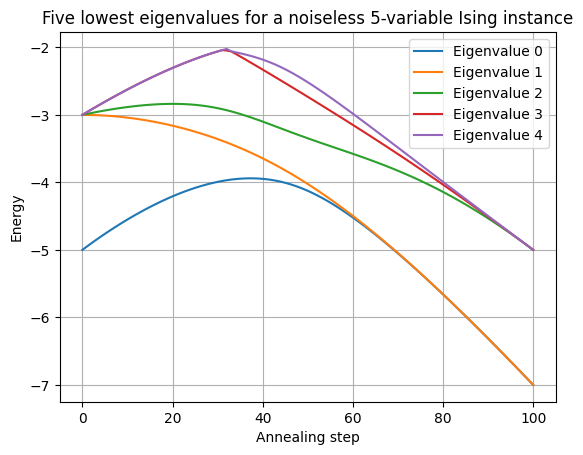

In [37]:
sim.plot_eigenvalues(
    small_eigenvalues_history,
    title="Five lowest eigenvalues for a noiseless 5-variable Ising instance"
)

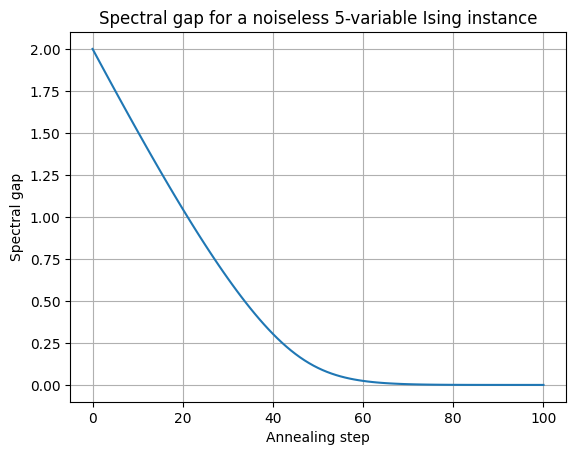

Gap minimal : 0.0
Étape du gap minimal : 100


In [38]:
small_gap = sim.plot_spectral_gap(
    small_eigenvalues_history,
    title="Spectral gap for a noiseless 5-variable Ising instance"
)

print("Gap minimal :", small_gap.min())
print("Étape du gap minimal :", small_gap.argmin())

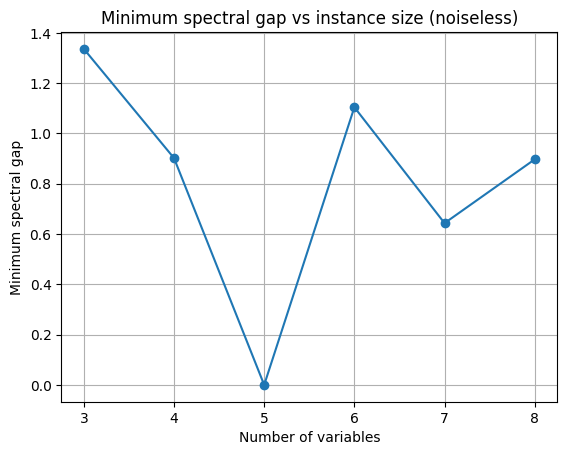

n = 3 -> min gap = 1.336004
n = 4 -> min gap = 0.901932
n = 5 -> min gap = 0.000000
n = 6 -> min gap = 1.104131
n = 7 -> min gap = 0.643234
n = 8 -> min gap = 0.896985


In [39]:
sizes = [3, 4, 5, 6, 7, 8]
min_gaps = []

for n in sizes:
    problem_n = sim.generate_random_ising_problem(
        n=n,
        weight_min=-1.0,
        weight_max=1.0,
        random_seed=42
    )

    eig_hist_n, _ = sim.simulate_evolution(
        problem_n,
        nb_eigenvalues=5
    )

    eig_hist_n = np.array(eig_hist_n, dtype=float)
    gap_n = eig_hist_n[:, 1] - eig_hist_n[:, 0]
    min_gaps.append(gap_n.min())

plt.figure()
plt.plot(sizes, min_gaps, marker="o")
plt.xlabel("Number of variables")
plt.ylabel("Minimum spectral gap")
plt.title("Minimum spectral gap vs instance size (noiseless)")
plt.grid(True)
plt.show()

for n, g in zip(sizes, min_gaps):
    print(f"n = {n} -> min gap = {g:.6f}")

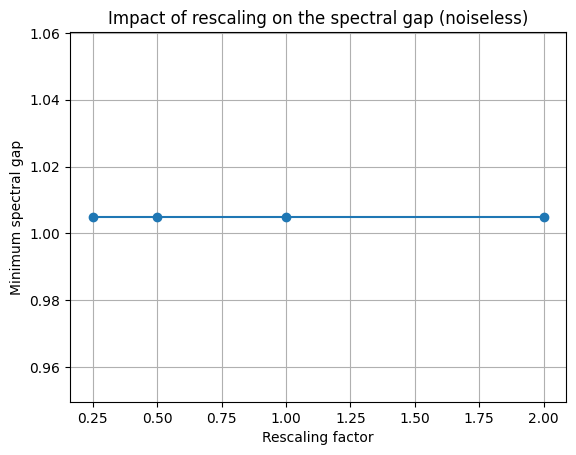

scale = 0.25 -> min gap = 1.004930
scale = 0.5 -> min gap = 1.004930
scale = 1.0 -> min gap = 1.004930
scale = 2.0 -> min gap = 1.004930


In [40]:
base_problem = sim.generate_random_ising_problem(
    n=5,
    weight_min=-1.0,
    weight_max=1.0,
    random_seed=123
)

scales = [0.25, 0.5, 1.0, 2.0]
scaled_min_gaps = []

for scale in scales:
    scaled_problem = sim.rescale_ising_problem(base_problem, scale)

    eig_hist_scaled, _ = sim.simulate_evolution(
        scaled_problem,
        nb_eigenvalues=5
    )

    eig_hist_scaled = np.array(eig_hist_scaled, dtype=float)
    gap_scaled = eig_hist_scaled[:, 1] - eig_hist_scaled[:, 0]
    scaled_min_gaps.append(gap_scaled.min())

plt.figure()
plt.plot(scales, scaled_min_gaps, marker="o")
plt.xlabel("Rescaling factor")
plt.ylabel("Minimum spectral gap")
plt.title("Impact of rescaling on the spectral gap (noiseless)")
plt.grid(True)
plt.show()

for scale, g in zip(scales, scaled_min_gaps):
    print(f"scale = {scale} -> min gap = {g:.6f}")

## Discussion

For the 5-variable noiseless Ising instance, the five lowest eigenvalues evolve smoothly during the annealing process.  
The spectral gap decreases significantly and becomes very small near the end of the evolution. This means that the system becomes more sensitive in the final part of the annealing, since the ground state and the first excited state get very close.

When comparing different instance sizes, the minimum spectral gap is not strictly monotonic in these tests, but the results show that the gap can become very small for some instances, such as the 5-variable case. In general, a smaller spectral gap indicates a harder adiabatic evolution, because the system is more likely to leave the ground state if the evolution is too fast.

For the rescaling study in the noiseless case, the minimum spectral gap remains almost unchanged for all tested scaling factors. This suggests that, in the ideal noiseless setting, rescaling the coefficients of the final Hamiltonian does not significantly affect the minimum spectral gap in this experiment.

Overall, these results show that the spectral gap is a key quantity for understanding the difficulty of the annealing process: the smaller the gap, the harder it is to remain in the ground state during the evolution.